<a href="https://colab.research.google.com/github/Moyohor/Machine_Learning_Projects/blob/main/Copy_of_Log_File_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT REQUIRED LIBRARIES


In [ ]:
import pandas as pd
import numpy as np

# 1. Load your anomaly/log dataset
# (Adjust the filename to match your exact uploaded CSV)
df = pd.read_csv('/content/sample_data/credit_card_fraud_10k.csv')

# 2. Print shape and columns
print(f"Dataset Shape: {df.shape} (Rows, Columns)")
print("\nFirst 3 rows of the log data:")
print(df.head(3))

# 3. Look at the data types to ensure they are numerical
print("\nData Types overview:")
print(df.dtypes.value_counts())


Dataset Shape: (10000, 10) (Rows, Columns)

First 3 rows of the log data:
   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  

Data Types overview:
int64      8
float64    1
object     1
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Separate features from the evaluation label
# We save 'is_fraud' purely to grade our model's performance later
y_eval = df['is_fraud']
X_raw = df.drop(['transaction_id', 'is_fraud'], axis=1)

# 2. One-Hot Encode the text column ('merchant_category')
X_encoded = pd.get_dummies(X_raw, columns=['merchant_category'])

# 3. Scale the numerical columns (crucial for uniform anomaly analysis)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Data processing complete!")
print(f"Features matrix shape: {X_scaled.shape}")
print(f"Total known anomalies in dataset: {y_eval.sum()}")


Data processing complete!
Features matrix shape: (10000, 12)
Total known anomalies in dataset: 151


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# 1. Initialize the Isolation Forest
# contamination=0.05 means we assume roughly 5% of the logs are anomalies
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# 2. Train the model on the scaled features
# Notice we DO NOT pass y_eval here—this is pure unsupervised learning
iso_forest.fit(X_scaled)

# 3. Generate predictions (-1 for anomaly, 1 for normal)
raw_predictions = iso_forest.predict(X_scaled)

# 4. Map the model's output (-1 and 1) to match our evaluation label (1 and 0)
# This lets us run a standard classification report to grade the model
mapped_predictions = [1 if pred == -1 else 0 for pred in raw_predictions]

# 5. Print the Evaluation Report
print("================ UNSUPERVISED ANOMALY DETECTION REPORT ================")
print(classification_report(y_eval, mapped_predictions, target_names=['Normal Log', 'Anomaly/Threat']))


================ UNSUPERVISED ANOMALY DETECTION REPORT ================
                precision    recall  f1-score   support

    Normal Log       1.00      0.96      0.98      9849
Anomaly/Threat       0.21      0.69      0.32       151

      accuracy                           0.96     10000
     macro avg       0.60      0.82      0.65     10000
  weighted avg       0.98      0.96      0.97     10000



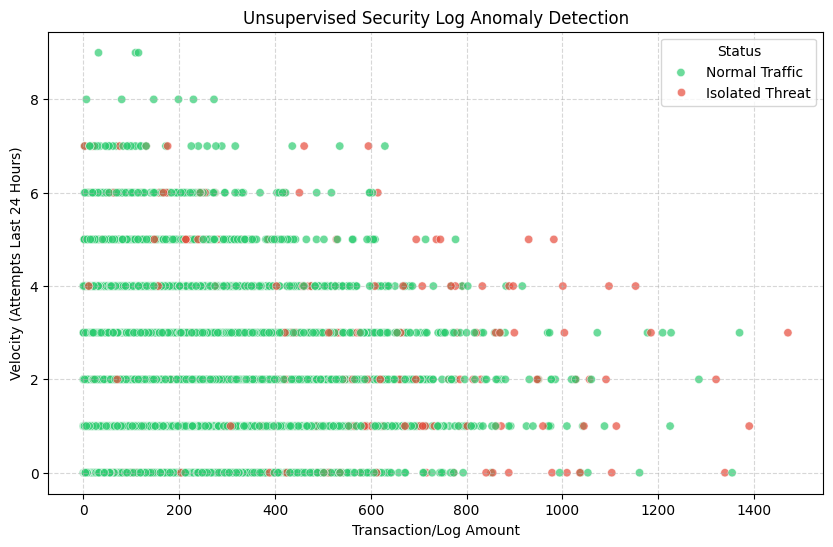

Visualization generated and unsupervised model files saved successfully!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# 1. Add predictions back to a temporary DataFrame for plotting
plot_df = pd.DataFrame(X_encoded, columns=X_encoded.columns)
plot_df['Anomaly_Status'] = raw_predictions  # 1 = Normal, -1 = Anomaly

# 2. Plot the anomalies vs normal logs
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='amount',
    y='velocity_last_24h',
    hue='Anomaly_Status',
    palette={1: '#2ecc71', -1: '#e74c3c'}, # Green for normal, Red for threat
    data=plot_df,
    alpha=0.7
)
plt.title('Unsupervised Security Log Anomaly Detection')
plt.xlabel('Transaction/Log Amount')
plt.ylabel('Velocity (Attempts Last 24 Hours)')
plt.legend(title='Status', labels=['Normal Traffic', 'Isolated Threat'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Save the trained Unsupervised Model and Scaler
with open('anomaly_isolation_forest.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)

with open('anomaly_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Visualization generated and unsupervised model files saved successfully!")
